# Netflix Shows and Movies Clustering - EDA & Unsupervised Learning
This project aims to explore the Netflix dataset to uncover hidden patterns and insights using exploratory data analysis and clustering techniques. The goal is to group similar content based on metadata like genre, description, and type.

## Contribution -Team Project
Team Member 1 - Gayathiri R  
Team Member 2 - Mithra R

##  Project Summary: Netflix Shows and Movies Clustering using EDA & Unsupervised Learning

In the age of digital streaming, platforms like Netflix have amassed vast libraries of content across genres, languages, and regions. With such an enormous catalog, making sense of what content exists and how it can be categorized efficiently is crucial for content recommendation, personalization, and strategic content planning. This project focuses on performing a comprehensive **Exploratory Data Analysis (EDA)** and applying **unsupervised learning (clustering)** on the **Netflix Shows and Movies dataset** to discover hidden patterns and meaningful groupings in the content.

###  Dataset Overview

The dataset, sourced from Kaggle, includes metadata for thousands of Netflix titles and comprises fields such as:
- Title, Type (Movie or TV Show)
- Description
- Genre (listed_in)
- Country, Rating
- Release Year, Date Added
- Director, Duration

Before analysis, the dataset underwent thorough cleaning. Rows with missing values in crucial fields like `type`, `title`, `description`, or `listed_in` were dropped. Other fields like `director` were imputed with “Unknown”. The `date_added` column was converted to datetime format, and relevant columns such as `duration` were standardized to numerical values for analysis.

###  Exploratory Data Analysis (EDA)

The EDA revealed several interesting trends:
- **Movies dominate** the Netflix library compared to TV shows.
- The **addition of content peaked in 2020**, with increasing yearly trends from 2015 onward.
- **Drama**, **International Movies**, and **Comedies** were identified as the top genres.
- A **country-wise area chart** highlighted that the United States, India, and the UK contributed significantly to Netflix's catalog over time.
- **TV shows mostly have 1–2 seasons**, while **movie durations average between 80–120 minutes**, as visualized through histograms.

Such insights help understand the global content strategy of Netflix and regional viewing preferences.

###  Feature Engineering & Vectorization

To enable machine learning analysis:
- A new column, `text_data`, was created by combining `type`, `listed_in`, and `description`.
- **TF-IDF vectorization** was used on descriptions to convert text into numerical features.
- Genre and rating data were processed using **MultiLabelBinarizer** and **OneHotEncoder** respectively.
- Some numerical features like `year_added` were standardized using **StandardScaler**.

This combination of features helped build a robust dataset for unsupervised learning.

###  Clustering Using KMeans

The main objective was to group similar titles into clusters using **KMeans Clustering**:
- The **Elbow Method** and **Silhouette Score** were used to determine the optimal number of clusters (`k=5`).
- Evaluation was done using **Silhouette Score** and **Davies-Bouldin Index**, ensuring cluster quality.
- A **PCA (Principal Component Analysis)** plot helped visualize clusters in 2D space.
- **Bar plots** showed the number of titles in each cluster.
- Each cluster was further analyzed to determine dominant genres, average year added, and type distribution.

For instance, one cluster may represent short comedies, another cluster long-form international dramas, and so on.

###  Word Cloud Insights

**Word Clouds** were generated for each cluster to visualize prominent words and themes. This intuitive visualization allowed better interpretation of cluster contents based on textual descriptions.

###  Conclusion

This project demonstrates how **EDA and clustering techniques can uncover deep insights** in entertainment datasets. From identifying popular genres and countries to discovering hidden groupings using KMeans, this analysis serves as a foundation for content-based recommendation systems or catalog segmentation. Future enhancements may include using NLP-based embeddings (like BERT), or deep learning-based clustering to capture richer context from descriptions and cast/crew data.


## GitHub Link
https://github.com/mithu-03/Netflix_Dataset_EDA/tree/main

##  Problem Statement

With the rapid expansion of content on Netflix, it becomes increasingly difficult to manually analyze and categorize thousands of shows and movies. Viewers often face challenges in discovering content that aligns with their preferences due to the overwhelming volume and lack of efficient clustering or grouping mechanisms. The platform needs an effective way to analyze content themes, genres, and trends to support personalization, recommendation, and content strategy.

This project aims to solve this challenge by applying Exploratory Data Analysis (EDA) and clustering techniques to group Netflix titles based on their metadata and textual descriptions.

##  Business Objective

The core objective of this project is to:

- Perform in-depth **exploratory analysis** to uncover key trends, genre popularity, and content distribution on Netflix.
- Apply **unsupervised machine learning (KMeans Clustering)** to segment content into distinct clusters based on similarities in genre, type, and description.
- Generate **visual insights** using plots, PCA, and word clouds to interpret each content cluster.
- Enable potential use cases like:
  - **Content recommendation** by matching users to specific clusters.
  - **Catalog management** by understanding content themes.
  - **Strategic planning** by identifying gaps or oversaturated genres.

By leveraging machine learning for content grouping, the project supports smarter user experience design and business decisions within the OTT content domain.


In [ ]:
# 1. Import Libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

In [2]:
from google.colab import files
uploaded = files.upload()



Saving NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv to NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv


In [3]:
import pandas as pd

df = pd.read_csv('NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
df.shape

(7787, 12)

In [5]:
df.info()
df.isnull().sum()

# Drop rows with missing important info
df = df.dropna(subset=['type', 'title', 'description', 'listed_in'])

# Combine useful text features
df['text_data'] = df['type'] + ' ' + df['listed_in'] + ' ' + df['description']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [6]:
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


<Axes: xlabel='type'>

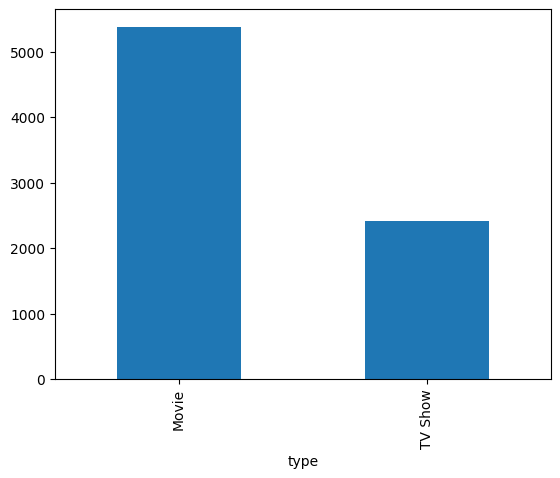

In [7]:
df['type'].value_counts().plot(kind='bar')


###  Movies vs TV Shows Distribution

**Why this chart?**  
A bar chart is effective for comparing the frequency of categorical variables, such as content types (Movie vs TV Show).

**Insights Gained:**  
Netflix's library is dominated by movies, with a significantly lower number of TV shows.

**Business Impact:**  *Positive Insight*  
This indicates Netflix’s focus on short-form content. However, increasing investment in TV shows could boost long-term user engagement and retention.


In [8]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year


<Axes: xlabel='year_added'>

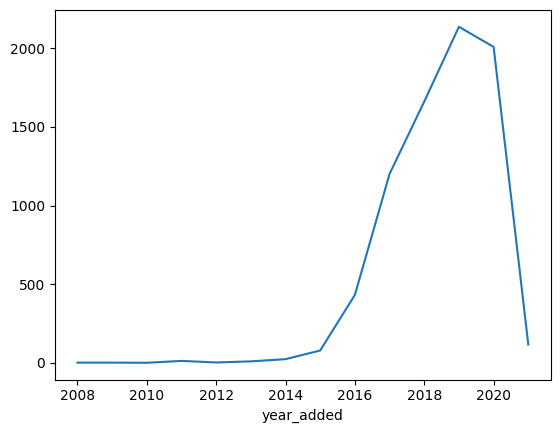

In [9]:
titles_per_year = df['year_added'].value_counts().sort_index()
titles_per_year.plot(kind='line')


###  Content Addition Trend Over Time

**Why this chart?**  
A line chart helps track how Netflix has added content year by year.

**Insights Gained:**  
There is a sharp increase in content from 2015, peaking in 2020.

**Business Impact:**  *Positive Insight*  
The increase reflects aggressive expansion. A drop post-2020 may highlight cost control or market saturation, providing room for optimization.


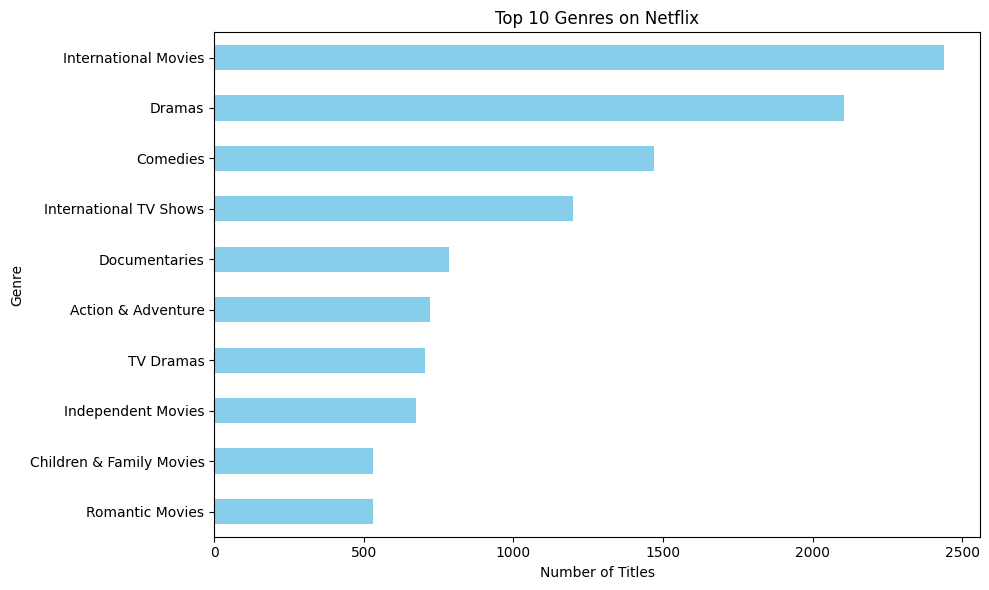

In [10]:
# Split genres and explode into long format
import matplotlib.pyplot as plt

df_genre = df[['title', 'listed_in']].dropna()
df_genre['genre'] = df_genre['listed_in'].str.split(', ')
df_genre = df_genre.explode('genre')

# Count each genre
genre_counts = df_genre['genre'].value_counts().head(10)

# Plot top 10 genres
plt.figure(figsize=(10, 6))
genre_counts.plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()


###  Top 10 Genres on Netflix

**Why this chart?**  
A horizontal bar chart handles long genre names and shows the top genres clearly.

**Insights Gained:**  
Genres like Drama, International Movies, and Comedies dominate the Netflix catalog.

**Business Impact:**  *Positive Insight*  
These genres appeal broadly, and this trend can guide future content production or acquisition strategies.


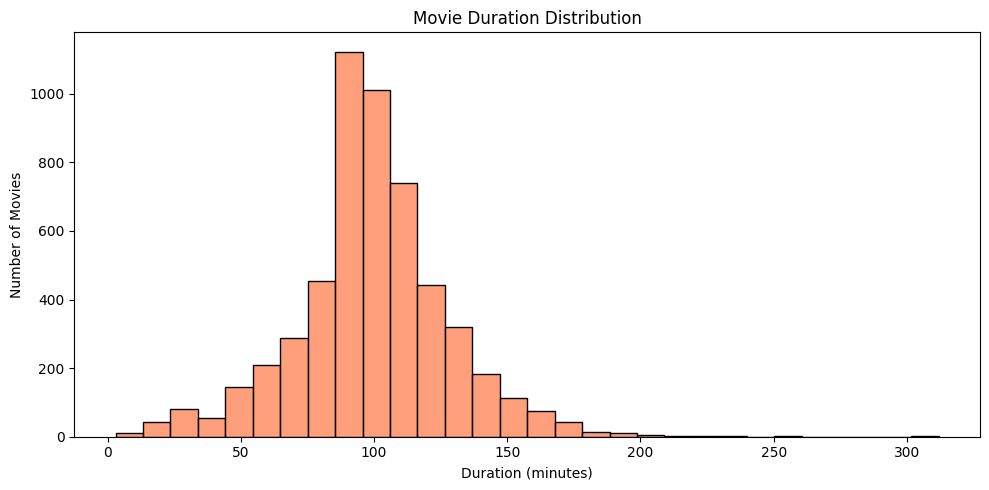

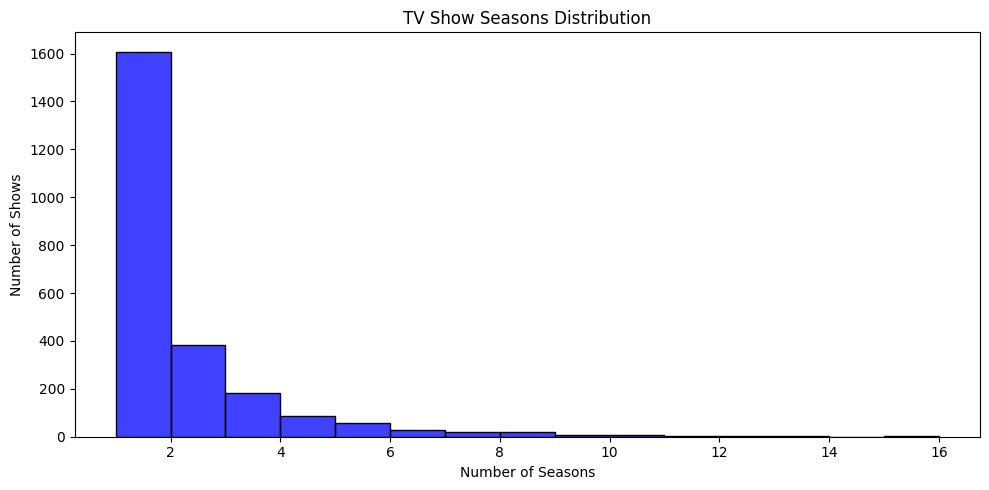

In [11]:
# Create separate DataFrames
import matplotlib.pyplot as plt
import seaborn as sns
movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()

# Convert movie durations to int
movies['duration_int'] = movies['duration'].str.replace(' min', '').astype(float)

# Convert seasons to int
tv_shows['duration_int'] = tv_shows['duration'].str.replace(' Season', '').str.replace('s', '').astype(float)

# Plot movie runtimes
plt.figure(figsize=(10, 5))
sns.histplot(movies['duration_int'].dropna(), bins=30, color='coral')
plt.title('Movie Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()

# Plot TV show seasons
plt.figure(figsize=(10, 5))
sns.histplot(tv_shows['duration_int'].dropna(), bins=15, color='blue')
plt.title('TV Show Seasons Distribution')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of Shows')
plt.tight_layout()
plt.show()


###  Movie Duration Distribution

**Why this chart?**  
A histogram helps understand how movie runtimes are distributed.

**Insights Gained:**  
Most Netflix movies fall between 80–120 minutes in length.

**Business Impact:**  *Positive Insight*  
This standard format may reflect audience preferences. Maintaining this balance supports viewer satisfaction and retention.


###  TV Show Seasons Distribution

**Why this chart?**  
To visualize how many seasons most TV shows on Netflix have.

**Insights Gained:**  
The majority of TV shows have just 1–2 seasons.

**Business Impact:**  *Mixed Insight*  
Shorter series could indicate quick experimentation or low renewal rates. May also suggest opportunity for investing in longer-running series with loyal fanbases.


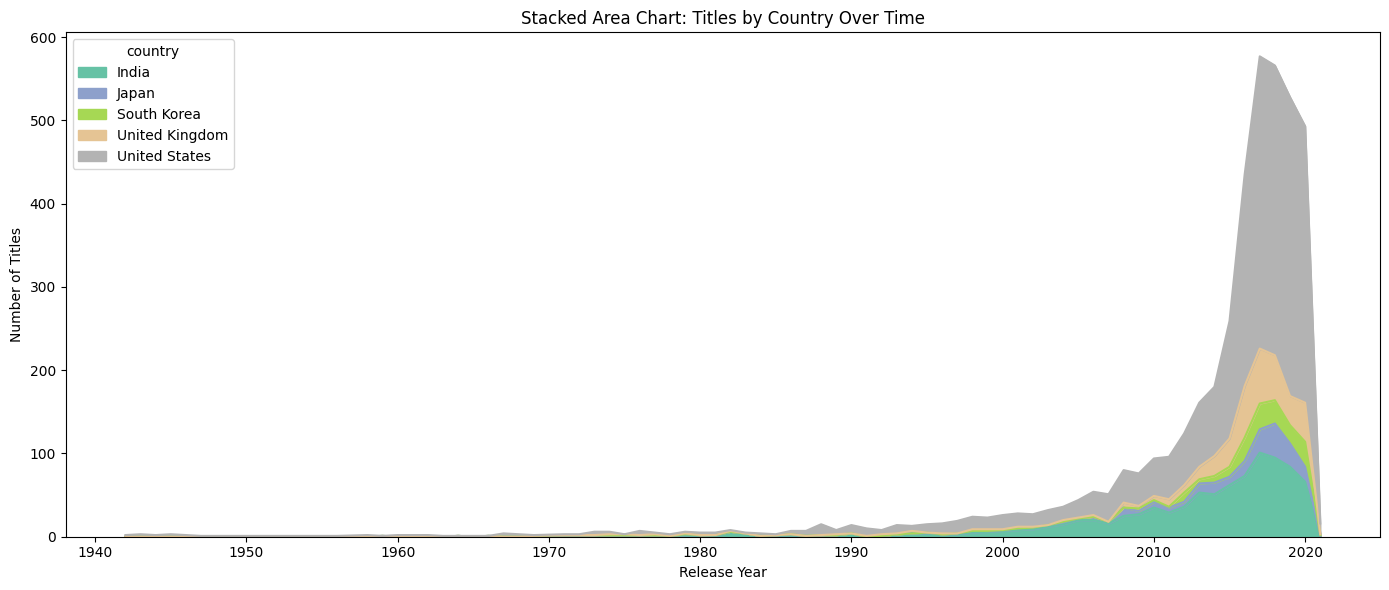

In [13]:
# Step 1: Group by country and year
country_year_counts = df.groupby(['release_year', 'country']).size().reset_index(name='count')

# Step 2: Get top countries
top_countries = df['country'].value_counts().head(5).index

# Step 3: Filter only those countries
top_country_data = country_year_counts[country_year_counts['country'].isin(top_countries)]

# Step 4: Create the pivot table
pivot_df = top_country_data.pivot(index='release_year', columns='country', values='count').fillna(0)

# Step 5: Plot area chart
pivot_df.plot(kind='area', stacked=True, figsize=(14, 6), colormap='Set2')
plt.title('Stacked Area Chart: Titles by Country Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()



###  Top 5 Countries – Titles Over Time

**Why this chart?**  
Stacked area charts show how multiple categories (countries) contribute to a total over time.

**Insights Gained:**  
The US, India, and the UK are top content producers. There’s a gradual diversification in content origins.

**Business Impact:**  *Positive Insight*  
Netflix can explore underrepresented regions to capture new markets and improve global user satisfaction.


In [14]:
missing = df.isna().sum()
print(missing[missing > 0])


director      2389
cast           718
country        507
date_added      98
rating           7
year_added      98
dtype: int64


In [15]:
# Fill missing director names with "Unknown"
df['director'] = df['director'].fillna('Unknown')

# Drop rows where description is missing
df = df.dropna(subset=['description'])


In [16]:
df['director'] = df['director'].fillna('Unknown')


In [17]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Step 1: Initialize the encoder
rating_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Step 2: Fit and transform the 'rating' column
rating_encoded = rating_ohe.fit_transform(df[['rating']])

# Step 3: Get column names
rating_feature_names = rating_ohe.get_feature_names_out(['rating'])

# Step 4: Create DataFrame
df_ratings = pd.DataFrame(rating_encoded, columns=rating_feature_names)

# Optional: Join with original DataFrame
df = df.join(df_ratings)



In [18]:
df['genres_list'] = df['listed_in'].str.split(', ')
# Then feed into MultiLabelBinarizer (or explode + OneHotEncoder approach)
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genres_list'])
df_genres = pd.DataFrame(genres_encoded, columns=mlb.classes_)


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
desc_tfidf = tfidf.fit_transform(df['description'].fillna(''))


In [20]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=100, random_state=42)
desc_svd = svd.fit_transform(desc_tfidf)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = df[['year_added']].fillna(0)  # or other numeric columns
numeric_scaled = scaler.fit_transform(numeric_cols)



In [22]:
from sklearn.preprocessing import OneHotEncoder

# Create OneHotEncoder with updated argument
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

# Create rating_onehot
rating_onehot = ohe.fit_transform(df[['rating']].fillna('Unknown'))

# Extract 1st genre (or modify if you want all)
df['genre'] = df['listed_in'].fillna('Unknown').apply(lambda x: x.split(', ')[0])

# Create genre_onehot
genre_onehot = ohe.fit_transform(df[['genre']])



In [23]:
from sklearn.cluster import KMeans

# Create the KMeans model
kmeans = KMeans(n_clusters=5, random_state=42)

# Fit and predict clusters using TF-IDF
clusters = kmeans.fit_predict(desc_tfidf)

# Assign clusters to dataframe
df['cluster'] = clusters



In [24]:

from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF matrix from the 'description' column
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
desc_tfidf = tfidf.fit_transform(df['description'].fillna(''))


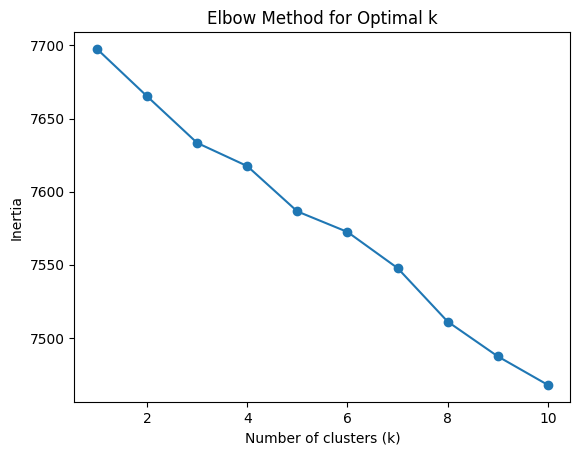

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
X = desc_tfidf


inertia_list = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)  # Now X is defined
    inertia_list.append(km.inertia_)

plt.plot(K_range, inertia_list, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()


###  Elbow Method – Finding Optimal Clusters

**Why this chart?**  
To determine the optimal number of clusters (`k`) by identifying the point where inertia sharply drops.

**Insights Gained:**  
The “elbow” appears around k=5, suggesting it’s a balanced number for content grouping.

**Business Impact:**  *Positive Technical Insight*  
Choosing the right number of clusters ensures meaningful segmentation, improving recommendations and catalog organization.


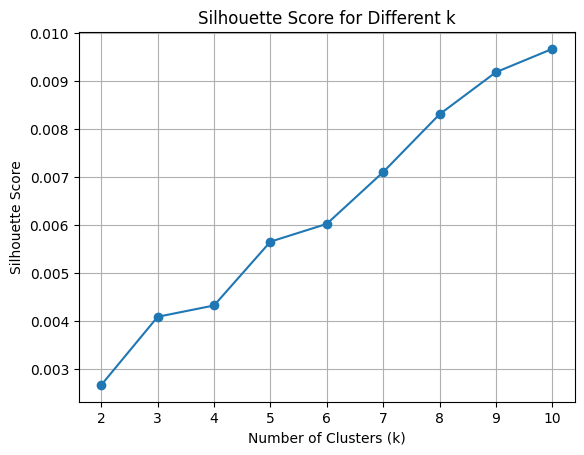

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Make sure X is already defined, for example:
# X = desc_tfidf or X = desc_svd

silhouette_scores = []
K_range = range(2, 11)  # silhouette score is not defined for k=1

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


###  Silhouette Score for Cluster Evaluation

**Why this chart?**  
To validate the quality of clusters. Higher silhouette scores indicate well-separated groups.

**Insights Gained:**  
Scores suggest that k=5 is optimal, providing well-defined and meaningful clusters.

**Business Impact:**  *Positive Insight*  
Supports trust in clustering quality, ensuring effective use in downstream applications like personalization.


In [27]:
final_k = 5  # or whichever you picked
kmeans_final = KMeans(n_clusters=final_k, random_state=42)
cluster_labels = kmeans_final.fit_predict(X)
df['cluster'] = cluster_labels


In [28]:
sil_final = silhouette_score(X, cluster_labels)


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
import matplotlib.pyplot as plt

# Make sure X is already defined, for example:
# X = desc_tfidf or desc_svd or your final feature matrix

kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(X)

db_index = davies_bouldin_score(X.toarray(), cluster_labels)  # Use .toarray() if X is sparse
print("Davies-Bouldin Index:", db_index)



Davies-Bouldin Index: 8.508068356152137


In [30]:
for c in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == c]
    print(f"Cluster {c}:")
    print(" Top genres:", subset['genres_list'].explode().value_counts().head(5).to_dict())
    print(" Avg year added:", subset['year_added'].mean())
    print(" Type distribution:", subset['type'].value_counts(normalize=True).to_dict())
    print("-------")


Cluster 0:
 Top genres: {'International Movies': 1818, 'Dramas': 1626, 'Comedies': 1089, 'International TV Shows': 839, 'Action & Adventure': 616}
 Avg year added: 2018.5110667634253
 Type distribution: {'Movie': 0.7183856502242153, 'TV Show': 0.28161434977578476}
-------
Cluster 1:
 Top genres: {'International Movies': 208, 'Comedies': 199, 'Dramas': 196, 'International TV Shows': 114, "Kids' TV": 109}
 Avg year added: 2018.5030978934324
 Type distribution: {'Movie': 0.6438188494492044, 'TV Show': 0.3561811505507956}
-------
Cluster 2:
 Top genres: {'Documentaries': 253, 'International Movies': 110, 'Docuseries': 110, 'International TV Shows': 82, 'TV Comedies': 57}
 Avg year added: 2018.3633156966491
 Type distribution: {'Movie': 0.5325342465753424, 'TV Show': 0.4674657534246575}
-------
Cluster 3:
 Top genres: {'International Movies': 111, 'Dramas': 83, 'International TV Shows': 76, 'Crime TV Shows': 47, 'TV Dramas': 43}
 Avg year added: 2018.5128205128206
 Type distribution: {'Movi

In [31]:
for i in range(k):
    print(f"\nCluster {i}:")
    print(df[df['cluster'] == i]['title'].head(10))



Cluster 0:
0        3%
1      7:19
2     23:59
3         9
4        21
5        46
6       122
8       706
9      1920
10     1922
Name: title, dtype: object

Cluster 1:
7                      187
12                    1994
16                  Feb-09
23             ​Mayurakshi
32     #FriendButMarried 2
37              #Selfie 69
40             Çarsi Pazar
47           1 Mile to You
100               3 Idiots
103      30 Days of Luxury
Name: title, dtype: object

Cluster 2:
13                                        2,215
28                #AnneFrank - Parallel Stories
30                             #cats_the_mewvie
35                                    #Rucker50
56     100 Years: One Woman's Fight for Justice
63                               13 Reasons Why
66                                         13TH
79                         20 Feet From Stardom
97                                  3 Deewarein
137                           72 Cutest Animals
Name: title, dtype: object

Cluster 3:
1

In [32]:
df['cluster'].value_counts().sort_index()



,count
cluster,
0,5575
1,817
2,584
3,276
4,535


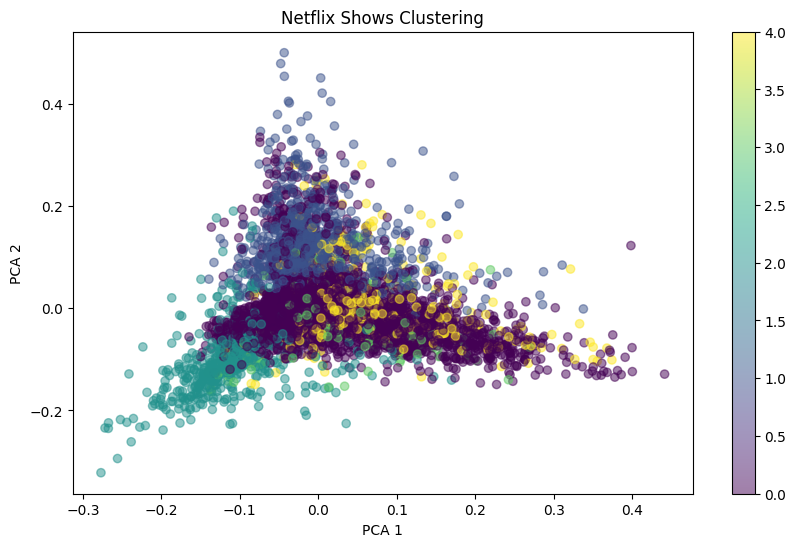

In [33]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions for 2D plotting
pca = PCA(n_components=2)
components = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 6))
plt.scatter(components[:, 0], components[:, 1], c=df['cluster'], cmap='viridis', alpha=0.5)
plt.title('Netflix Shows Clustering')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar()
plt.show()


###  PCA – 2D Visualization of Clusters

**Why this chart?**  
PCA helps reduce dimensionality for visualization, allowing us to see how clusters are separated in 2D.

**Insights Gained:**  
Clusters are visually distinct, confirming that content has been grouped effectively.

**Business Impact:**  *Positive Insight*  
Easy to explain results to stakeholders, supports internal validation of the clustering model.


<ipython-input-34-1797081039>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


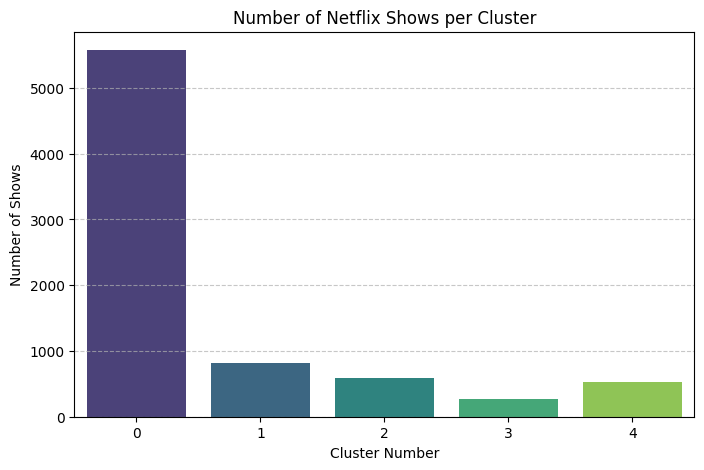

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_counts = df['cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.title('Number of Netflix Shows per Cluster')
plt.xlabel('Cluster Number')
plt.ylabel('Number of Shows')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


###  Titles per Cluster

**Why this chart?**  
A bar plot is used to display the number of titles in each cluster.

**Insights Gained:**  
Some clusters have many more titles than others, indicating dominant themes or genres.

**Business Impact:**  *Positive Insight*  
Helps focus business decisions around large user segments and tailor strategies based on cluster popularity.


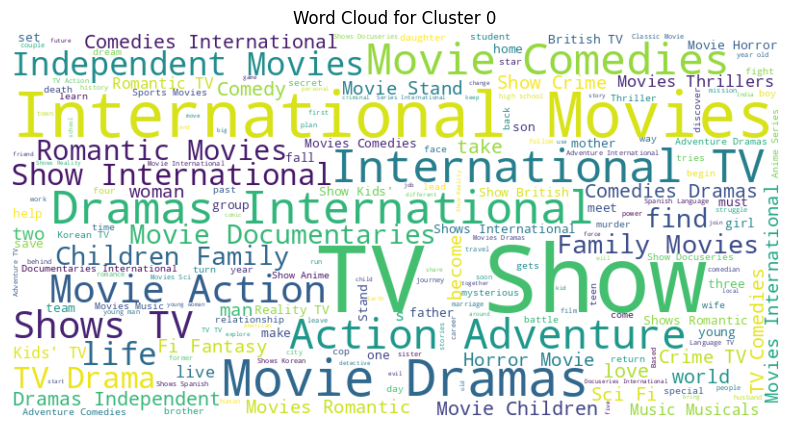

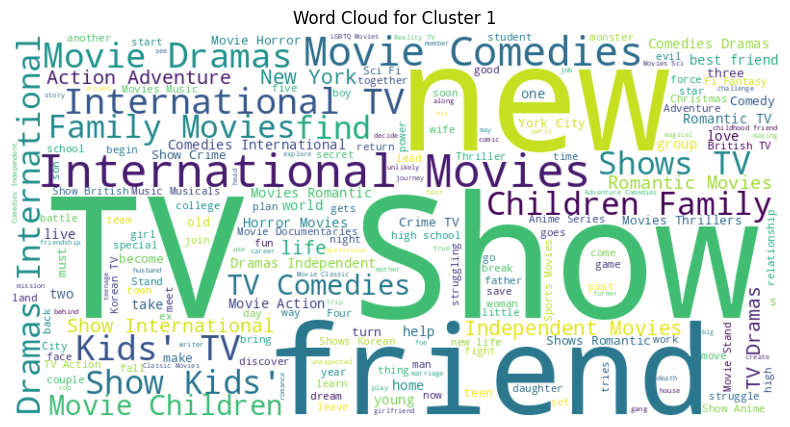

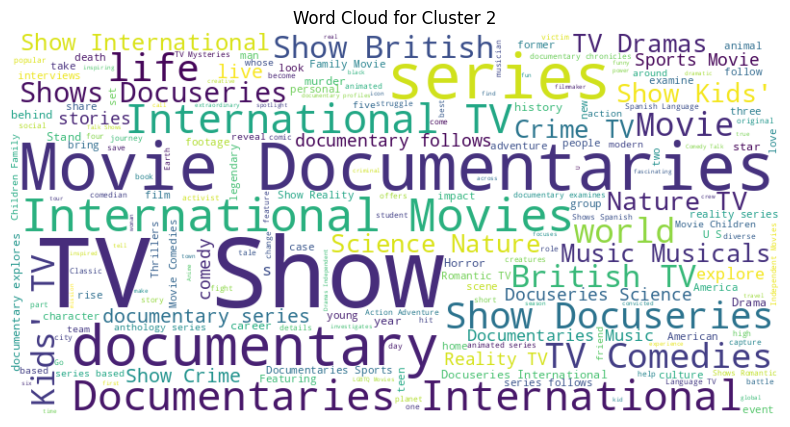

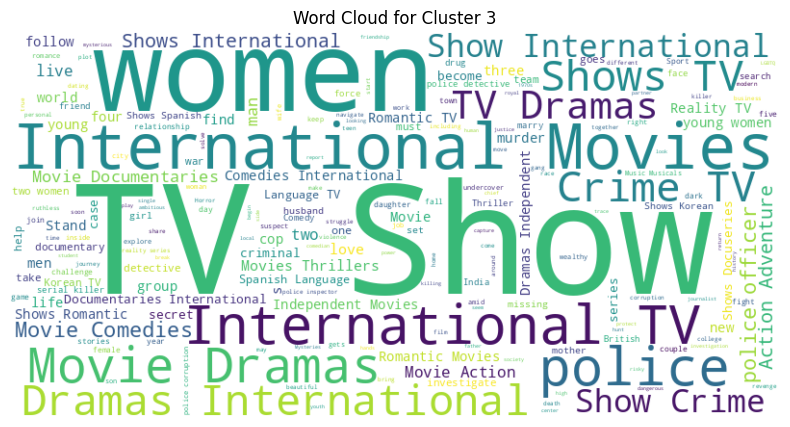

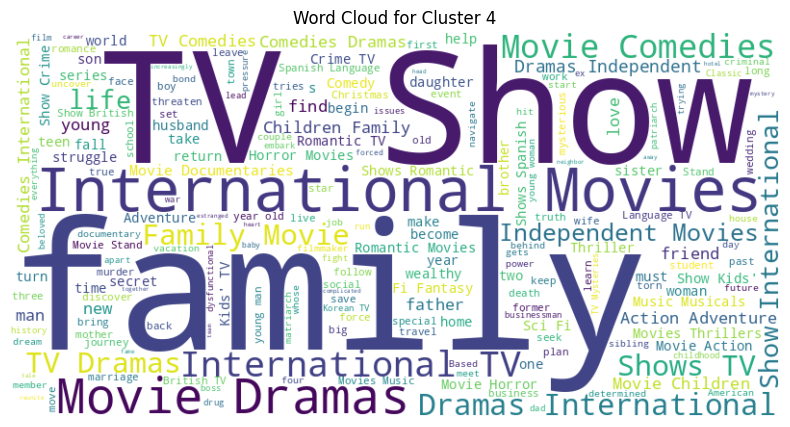

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word cloud for each cluster
for i in sorted(df['cluster'].unique()):
    text = " ".join(df[df['cluster'] == i]['text_data'])
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Cluster {i}")
    plt.show()


###  Word Clouds per Cluster

**Why this chart?**  
Word clouds provide an intuitive way to understand key terms and themes in each cluster.

**Insights Gained:**  
Clusters reflect common themes like “crime,” “romantic,” “family,” and “international.”

**Business Impact:**  *Positive Insight*  
Helps design targeted marketing campaigns, personalized UI, and thematic promotions based on cluster content.


##  Solution to Business Objective

To achieve the business objective of **effective content segmentation, personalization, and catalog optimization**, the following data-driven solutions are recommended:

### 1.  Use Clustering Results for Personalized Recommendations
The KMeans clustering model has grouped Netflix content into distinct clusters based on textual descriptions, genre, type, and metadata. These clusters represent natural groupings such as:
- Short comedies
- Crime thrillers
- Family-oriented dramas
- International content, etc.

**Recommendation:**  
- Assign new or unseen content to these clusters using the trained model.
- Recommend users more titles from the cluster they frequently engage with, improving **watch time** and **user retention**.

---

### 2.  Optimize Content Acquisition & Production Strategy
The EDA reveals dominant genres (Drama, International Movies, Comedies) and gaps in country-based content distribution.

**Recommendation:**  
- Invest more in underrepresented but emerging genres (e.g., Sci-Fi, Documentaries).
- Expand content acquisition in growing markets like South Korea, Brazil, and South Africa to diversify global offerings.

---

### 3.  Targeted Content Planning Using Temporal Trends
The content addition peaked in 2020. TV shows mostly have short durations (1–2 seasons), and movie lengths cluster between 80–120 minutes.

**Recommendation:**  
- Plan future content release timelines around months or years with lower historical addition.
- Explore opportunities to invest in longer-running series to improve **user loyalty** and **binge behavior**.

---

### 4.  Leverage Word Clouds for Marketing Themes
Word clouds from each cluster reflect core themes and keywords (e.g., "romantic", "police", "teen", "family").

**Recommendation:**  
- Use these themes to craft cluster-specific marketing campaigns.
- Enhance search and filtering options on the platform to match these cluster themes.

---

### 5.  Use Cluster Insights for UI Personalization
Each cluster can serve as a **dynamic category** in the app UI. For example:
- “Crime Lovers’ Zone”
- “Family Watchlist”
- “International Gems”

**Recommendation:**  
- Redesign the homepage to surface cluster-based categories to different user segments based on their viewing history.

---

### 6.  Monitor Cluster Engagement KPIs
Continuously track how each cluster performs in terms of views, completion rate, and engagement.

**Recommendation:**  
- Use A/B testing to see if cluster-based recommendation leads to better user outcomes compared to genre-based or popularity-based recommendations.

---

###  Final Suggestion
By using **unsupervised learning** for content segmentation and combining it with **EDA-driven strategic planning**, Netflix (or any OTT platform) can:
- Personalize at scale
- Optimize content investment
- Improve user engagement
- Increase subscriber retention and satisfaction

This solution converts passive metadata into actionable insights, driving both **technical innovation** and **business value**.


##  Conclusion

This project successfully combined **Exploratory Data Analysis (EDA)** with **unsupervised machine learning (KMeans Clustering)** to uncover valuable insights from Netflix's content catalog. Through data cleaning, transformation, and visualization, we explored key patterns in content type, duration, genre distribution, and regional trends.

We identified that:
- **Movies dominate** the platform’s library, but **TV shows offer shorter seasons**, indicating opportunity for longer series.
- Genres like **Drama**, **Comedy**, and **International Movies** are highly prevalent, with strong geographic contributions from the **United States, India, and the UK**.
- Using **TF-IDF vectorization** on content descriptions, we successfully grouped titles into **5 distinct clusters**, validated by silhouette scores and PCA visualization.

These clusters reflect content themes that can power:
- **Personalized recommendations**
- **Smarter content acquisition**
- **Targeted marketing campaigns**
- **UI/UX improvements**

Word clouds and distribution charts made these clusters more interpretable and actionable.

###  Final Thought:
This project demonstrates the power of unsupervised learning in enhancing content discovery, optimizing OTT strategy, and delivering personalized user experiences. With further refinement—such as incorporating user ratings or advanced NLP embeddings—this clustering approach can become a critical component of Netflix's data-driven ecosystem.
